<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Spine_learning_as_a_dynamical_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Spine_learning_as_a_dynamical_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Itself Is a Dynamical System
### Zeroth-order LoRA post-training as a stochastic flow: the alignment cone, the spectral knee, and the drifting dimension

*(Working title for the paper. Alternate subtitles, same premise: "Invariants and symmetries of backprop-free adapter training" / "A flow-level theory of local post-training for diffusion models.")*

This notebook is the **spine**: every definition stated once, every result from Tiers 0–2 (and the Tier-2 extension) restated as a property of one dynamical system, each with a minimal runnable check (numpy, seconds) and a pointer to the full-scale evidence. Tiers 3–5 are then *formulated* — predictions registered before compute is spent, per the repo's staging rule.

Structure (the four spine moves, then the roadmap):

| § | Move |
|---|---|
| 0 | **Define the object once** — state space + update rule + conserved/dissipated quantities |
| 1–4 | **Restate each law as an invariance or structural property of the flow** (cone, dissipation, knee, reparametrization) |
| 5 | **The coupled state–operator element** — the effective dimension is itself a dynamical variable |
| 6 | **Where each piece lands** — the section-by-section map of the paper, with status (measured / derived / open) |
| 7–9 | **Tier 3 (diffusion backbone), Tier 4 (a different physics branch), Tier 5 (the dynamical-system demonstrations proper)** |

Evidence base: [`Tier0_alignment_laws_walkthrough.ipynb`](Tier0_alignment_laws_walkthrough.ipynb) · [`Tier1_diffusion_lora_walkthrough.ipynb`](Tier1_diffusion_lora_walkthrough.ipynb) · [`Tier2_estimation_cost_vs_rank.ipynb`](Tier2_estimation_cost_vs_rank.ipynb) · [`Tier2_extension_train_at_budget.ipynb`](Tier2_extension_train_at_budget.ipynb) · [`Theory_zeroth_order_lora_alignment.ipynb`](Theory_zeroth_order_lora_alignment.ipynb)

## §0 — The object, defined once

**Definition (the flow).** Zeroth-order LoRA post-training is the stochastic dynamical system

$$\theta_{t+1}=\theta_t-\eta_t\,\mathrm{Opt}\big(\hat g_t\big),\qquad \theta=(A,B)\in\mathbb{R}^{r\times n}\times\mathbb{R}^{m\times r},$$

where $\hat g_t$ is an **unbiased** zeroth-order estimate of $\nabla L(\theta_t)$ built from $M$ random probes at a chosen perturbation **site**, and the site fixes the noise geometry through one number, the effective dimension:

$$D_\text{eff}=\begin{cases}P=r(m+n) & \text{weight-space probes}\\ \bar d=(1-\beta)r+\beta m & \text{node-space (activation) probes.}\end{cases}$$

**The template, filled in:**

- **State space.** The adapter $\theta$ — optionally augmented with the slow variable $\beta_t$ (§5), giving the coupled system $(\theta,\beta)$.
- **Update rule.** Optimizer applied to an unbiased low-alignment gradient estimate; all estimator identity is carried by $D_\text{eff}$.
- **Dissipated quantity.** The loss $L$ (denoising loss downstream): the flow's Lyapunov-flavored statement is the per-step expected decrease of §2.
- **Conserved / invariant quantities.** Three, of different kinds:
  1. *Structural (exact, by construction):* $\mathbb{E}[\hat g_t]=\nabla L(\theta_t)$ for **any** $\theta$ and any probe budget. This is our analog of a conservation identity that holds independent of the learned configuration — true for garbage adapters too, so it validates bookkeeping, not physics; all physical content lives in the *variance*, i.e. in $D_\text{eff}$. (Compare: HPN's $\sum_iR_i=0$ telescoping identity, which likewise holds for arbitrary weights.)
  2. *Landscape (task-owned):* the singular spectrum of the optimal update $\Delta W^\ast$ — hence the spectral knee $r^\ast$ — is a constant of the **task**, untouched by estimator choice (§3).
  3. *Trajectory (band-limited symmetry):* the path in state space modulo time reparametrization, invariant under learning-rate rescaling inside a stability band (§4).

The minimal check below verifies the structural invariant and previews the cone: unbiasedness holds exactly; alignment does not.

In [ ]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

D, M, reps = 100, 8, 4000
g = rng.standard_normal(D); g /= np.linalg.norm(g)
X = rng.standard_normal((reps, M, D))
ghat = ((X @ g)[:, :, None] * X).mean(1)          # antithetic-exact ZO estimate, M probes
bias = np.linalg.norm(ghat.mean(0) - g)
c2 = (ghat @ g).mean()**2 / ((ghat**2).sum(1).mean() * (g @ g))
print(f"unbiasedness: ||E[ghat] - g|| = {bias:.3f}  (-> 0 as reps grow; exact in expectation)")
print(f"alignment:    cos^2 = {c2:.3f}  vs law M/(M+D+1) = {M/(M+D+1):.3f}")
print("the invariant is exact for any theta; the physics is in the variance -> D_eff")

unbiasedness: ||E[ghat] - g|| = 0.056  (-> 0 as reps grow; exact in expectation)
alignment:    cos^2 = 0.073  vs law M/(M+D+1) = 0.073
the invariant is exact for any theta; the physics is in the variance -> D_eff


## §1 — Law I: the alignment cone *(geometry of the drift field)*

**Flow statement.** The estimated drift $\hat g_M$ lives in a cone around the true gradient whose aperture is set by the effective dimension:

$$\cos^2\theta_\text{align}=\frac{M}{M+D_\text{eff}+1}.$$

This is Cauchy–Schwarz in parameter space (theory notebook §8): the probe average can align with $\nabla L$ only as fast as $M$ independent directions can span a $D_\text{eff}$-dimensional fluctuation. The site choice moves $D_\text{eff}$ from $P=r(m+n)$ to $\bar d\ll P$ — the entire node-vs-weight payoff is this one substitution in the cone law.

**Recorded evidence (full scale).**
- **Tier 0:** both laws hold on a real nonlinear loss; node curve rises far faster (pass condition $\bar d\ll P$).
- **Tier 1, Exp 1:** the laws hold under the actual denoising loss, with the *measured* $\beta$.
- **Tier 2:** fitted $D_\text{eff}(r)$ across ranks — weight slope **482.6** vs predicted $m{+}n=512$; node slope **1.30** vs predicted $\approx1{-}\beta$; the implied probes-to-alignment gap is two orders of magnitude at $H=256$.

Check: the cone law at several budgets.

In [ ]:
Ms = [1, 2, 4, 8, 16, 32, 64, 128]
print(f"{'M':>4} {'cos2 meas':>10} {'law':>7}")
for M in Ms:
    X = rng.standard_normal((3000, M, D))
    gh = ((X @ g)[:, :, None] * X).mean(1)
    c2 = (gh @ g).mean()**2 / ((gh**2).sum(1).mean() * (g @ g))
    print(f"{M:>4} {c2:>10.3f} {M/(M+D+1):>7.3f}")

   M  cos2 meas     law
   1      0.010   0.010
   2      0.019   0.019
   4      0.038   0.038
   8      0.074   0.073
  16      0.137   0.137
  32      0.241   0.241


  64      0.386   0.388


 128      0.558   0.559


## §2 — Law II: dissipation *(the flow's Lyapunov statement)*

**Flow statement.** Per step, with an unbiased estimate, $\mathbb{E}[\Delta L]=-\eta\|\nabla L\|^2+\tfrac{\eta^2}{2}\,\mathbb{E}[\hat g^\top H\hat g]$. The first term is alignment-independent — unbiasedness guarantees *downhill in expectation at small $\eta$ regardless of the cone.* The cone bites through the second term: $\mathbb{E}\|\hat g_M\|^2=\|g\|^2\frac{M+D_\text{eff}+1}{M}$, so the stable/optimal step shrinks by exactly the cone factor, and

$$\frac{\mathbb{E}[\Delta L]^\ast_\text{ZO}}{\mathbb{E}[\Delta L]^\ast_\text{backprop}}=\frac{M}{M+D_\text{eff}+1}=\cos^2\theta_\text{align}.$$

**Best-case per-step dissipation is the backprop dissipation scaled by the cone.** This is the bridge from §1 (geometry) to training outcomes (§3's floors, §5's budgets): estimation cost is a *dissipation-rate* deficit, nothing else. Open obligation 1 (finite-$\mu$, minibatch oracle) lives here.

Check: measure the optimal-step dissipation ratio on an isotropic quadratic.

In [ ]:
Dq = 60; th0 = rng.standard_normal(Dq); th0 /= np.linalg.norm(th0)   # L = 0.5||theta||^2, g = th0
Lq = lambda th: 0.5*(th*th).sum(-1)
dL_bp = -0.5*(th0@th0)                       # backprop optimal step (eta=1 for H=I): halves nothing—exact optimum
print(f"{'M':>4} {'meas ratio':>11} {'cos2 law':>9}")
for M in [2, 8, 32]:
    best = 0.0
    X = rng.standard_normal((4000, M, Dq))
    gh = ((X @ th0)[:, :, None] * X).mean(1)
    for eta in np.linspace(0.02, 1.0, 50):
        dL = (Lq(th0 - eta*gh) - Lq(th0)).mean()
        best = min(best, dL)
    print(f"{M:>4} {best/dL_bp:>11.3f} {M/(M+Dq+1):>9.3f}")

   M  meas ratio  cos2 law
   2       0.030     0.032
   8       0.115     0.116
  32       0.344     0.344


## §3 — Law III: the spectral knee is a landscape invariant

**Flow statement.** The loss-vs-rank knee $r^\ast$ is a property of the **landscape** (the singular spectrum of $\Delta W^\ast$, Eckart–Young), not of the flow that descends it. Corollary — the falsification asymmetry: any estimator given *sufficient* budget must reproduce the same knee; an estimator whose curve shows a **different** knee is not probing the landscape at all (its own noise floor is binding — "contamination").

**Recorded evidence (full scale).**
- **Tier 1, Exp 2:** backprop control knee at the injected $\rho=4$ (loss knee, with the honest anisotropic-Hessian caveat that the loss knee — not the Frobenius-energy knee — is operative).
- **Tier 2 extension:** knees **4 / 4 / 16** for control / node-at-budget / weight-at-matched-forward-passes — knee invariance for the adequately budgeted estimator, and the contamination signature *observed* for the starved one. Node reaches the control floor within 0.002–0.007 at every rank and never beats it (the estimator-independent lower bound respected).

Check: a planted low-rank task; exact gradients vs an adequately budgeted vs a starved ZO estimator.

In [ ]:
n_, m_, rho_ = 24, 24, 3
U,_ = np.linalg.qr(rng.standard_normal((m_, rho_))); V,_ = np.linalg.qr(rng.standard_normal((n_, rho_)))
Wstar = U @ np.diag([3.0, 2.0, 1.0]) @ V.T                 # planted spectrum -> knee at rho=3
floor = lambda r: 0.5*sum(s**2 for s in [3.0,2.0,1.0][r:])  # Eckart-Young floor
Lpl = lambda A,B: 0.5*np.sum((B@A - Wstar)**2)

def train(r, mode, M=0, steps=800, lr=0.03, seed=1):
    rg = np.random.default_rng(seed)
    A = rg.standard_normal((r, n_))/np.sqrt(n_); B = np.zeros((m_, r))
    for t in range(steps):
        E = B@A - Wstar; gA = B.T@E; gB = E@A.T
        if mode == "zo":
            g = np.concatenate([gA.ravel(), gB.ravel()]); Dz = g.size
            Xp = rg.standard_normal((M, Dz))
            ge = ((Xp @ g)[:, None] * Xp).mean(0)
            gA = ge[:r*n_].reshape(r, n_); gB = ge[r*n_:].reshape(m_, r)
        A -= lr*gA; B -= lr*gB
    return Lpl(A, B)

def fmt(v): return f"{v:7.3f}" if np.isfinite(v) else "    div"
ranks_ = [1, 2, 3, 4, 6, 8]
print(f"{'r':>2} {'EY floor':>9} {'exact':>7} {'ZO M=128':>9} {'ZO M=2':>7}")
for r in ranks_:
    with np.errstate(over="ignore", invalid="ignore"):
        starved = train(r, 'zo', 2, lr=0.01)
    print(f"{r:>2} {floor(r):>9.3f} {train(r,'exact'):>7.3f} {train(r,'zo',128):>9.3f} {fmt(starved)}")

 r  EY floor   exact  ZO M=128  ZO M=2
 1     2.500   2.500     2.500   2.500


 2     0.500   0.500     0.500   0.500
 3     0.000   0.000     0.000   0.060


 4     0.000   0.000     0.000   0.157


 6     0.000   0.000     0.000     div


 8     0.000   0.000     0.000     div


**How to read it.** Exact gradients and the adequately budgeted estimator both land on the Eckart–Young floor — same knee at the planted $\rho=3$, because the knee belongs to $\Delta W^\ast$'s spectrum. The starved column stops tracking the floor and then **destabilizes** as $r$ grows: Law II predicted exactly this — its stable step shrinks by $\cos^2\!\propto M/D$ with $D=48r$, so at a fixed lr the estimator, not the landscape, is what the curve measures. This is the toy form of the extension's 4/4/16 result (there the starved estimator was kept stable by Adam and showed a *moving knee* instead) — and the quotable sentence: **the rank you need is a property of the task, not the optimizer.**

## §4 — Law IV: reparametrization symmetry of the trajectory

**Flow statement.** Inside a stability band, the learning rate rescales *progress along* the trajectory, not the trajectory: loss curves at different $\eta$ collapse when plotted against cumulative path length $\sum_t\|\Delta\theta_t\|$ instead of steps. Outside the band the path itself changes — the symmetry breaks.

Adjacent precedent, honestly scoped: Hebbian Physics Networks (Auti, Daiguji & Tanaka, *PRR* **8**, 013309, 2026), Lemma 1 — in their setting the result is a joint-rescaling ODE reparametrization under adiabatic separation (their promotion/decay constants are *defined* to scale with the mobility), so it is weaker than its prose; our version is an **empirical stochastic** invariance, tested with plain SGD (Adam's normalization makes path length trivially $\propto\eta\times$steps) and common random numbers.

**Recorded evidence (full scale).** Tier 2 extension, Exp 2: node-ZO SGD at $r=8$, $\eta\in\{0.1,0.3,1.0\}$ collapse onto one loss-vs-path-length curve; $\eta=3.0$ leaves the band — different path, higher plateau, terminal instability.

Check: the same collapse on the planted task.

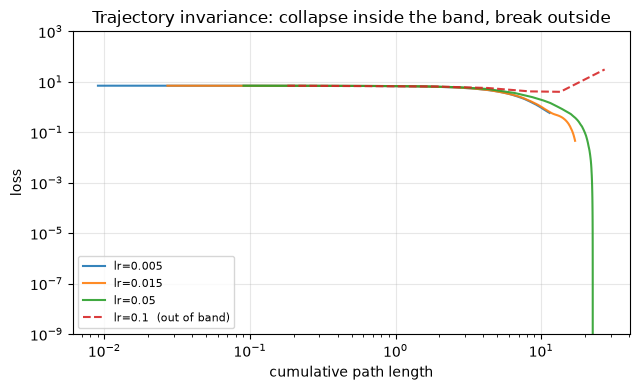

band edge sits between lr=0.05 (collapses onto the shared path) and lr=0.1 (diverges; curve truncated)


In [ ]:
def sgd_path(r, M, lr, steps=500, seed=3):
    rg = np.random.default_rng(seed)                       # common random numbers across lrs
    A = rg.standard_normal((r, n_))/np.sqrt(n_); B = np.zeros((m_, r))
    path, hist = 0.0, []
    for t in range(steps):
        E = B@A - Wstar; g = np.concatenate([(B.T@E).ravel(), (E@A.T).ravel()])
        Xp = rg.standard_normal((M, g.size))
        ge = ((Xp @ g)[:, None] * Xp).mean(0)
        dA = lr*ge[:r*n_].reshape(r, n_); dB = lr*ge[r*n_:].reshape(m_, r)
        A -= dA; B -= dB; path += np.sqrt((dA**2).sum()+(dB**2).sum())
        if not np.isfinite(path) or path > 3e2: break        # out-of-band: stop once the path runs away
        if t % 5 == 0:
            L_ = Lpl(A, B)
            if not np.isfinite(L_) or L_ > 1e3:              # out-of-band: record the exit and stop
                hist.append((path, 1e3)); break
            hist.append((path, L_))
    return np.array(hist)

plt.figure(figsize=(6.5, 4))
with np.errstate(over="ignore", invalid="ignore"):
    for lr, st in zip([0.005, 0.015, 0.05, 0.1], ["-", "-", "-", "--"]):
        h = sgd_path(3, 16, lr)
        plt.plot(h[:, 0], h[:, 1], st, label=f"lr={lr}" + ("  (out of band)" if lr == 0.1 else ""), alpha=.9)
plt.xscale("log"); plt.yscale("log"); plt.ylim(1e-9, 1e3)
plt.xlabel("cumulative path length"); plt.ylabel("loss")
plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("Trajectory invariance: collapse inside the band, break outside"); plt.tight_layout(); plt.show()
print("band edge sits between lr=0.05 (collapses onto the shared path) and lr=0.1 (diverges; curve truncated)")

## §5 — The coupled state–operator element: the dimension drifts

The genuinely HPN-flavored structure in our system — the operator that mediates the dynamics coevolving with the state — is not a metaphor; it is **$\beta_t$**. The node dimension $\bar d=(1-\beta)r+\beta m$ contains the gradient-energy split $\beta$, and $\beta$ is a function of the *current adapter*: training from the standard $B=0$ init starts with **all** gradient energy in $B$ ($\beta=1$, $\bar d\approx r+m$), then relaxes as $B$ fills in. So the honest state space is the coupled slow–fast system

$$(\underbrace{\theta_t}_{\text{fast}},\ \underbrace{\beta_t}_{\text{slow}}),\qquad \bar d_t=(1-\beta_t)r+\beta_t m,$$

and any budget set from a *reference* $\bar d$ (random adapter, as Tier 2 measures it) mis-prices the early flow.

**Recorded evidence (full scale).** Tier 2 extension: measured same-batch node:weight alignment ratio **22×**; predicted from the reference $\bar d$: ~**119×**; predicted from the training-time $\bar d\approx r+m$ (B-heavy phase): ~**21×**. The flow told us where to evaluate $\beta$.

**Spine claim (registered for Tier 3):** budgets must be set **on the trajectory** — measure $\beta_t$ online (cheap: one backprop or a few probes every few hundred steps) and adapt $M_n$; the static reference budget over- or under-spends by up to $(r+m)/\bar d_\text{ref}$ early in training.

Check: $\beta_t$ from the $B=0$ init on the planted task. It starts pinned at $1$ (B-heavy), relaxes non-monotonically, crosses the reference value on the way down, and — because this noiseless toy converges exactly — decays to $0$ as both gradient energies vanish. In stochastic training (the extension's regime) it hovers near the reference instead of vanishing. Either way, the reference-point value is the wrong number for the early flow.

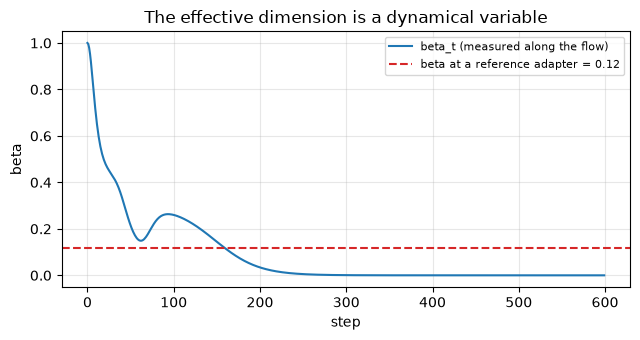

beta: t=0 -> 1.000 exactly (B-heavy phase, dbar~r+m=27) vs reference dbar=5.5
a budget priced at the reference underestimates the early node dimension by 4.9x


In [ ]:
r = 3
A = rng.standard_normal((r, n_))/np.sqrt(n_); B = np.zeros((m_, r))
Ar = rng.standard_normal((r, n_))/np.sqrt(n_); Br = rng.standard_normal((m_, r))/np.sqrt(r)
Er = Br@Ar - Wstar
beta_ref = np.sum((Er@Ar.T)**2)/(np.sum((Br.T@Er)**2)+np.sum((Er@Ar.T)**2))
bs_ = []
for t in range(600):
    E = B@A - Wstar; gA = B.T@E; gB = E@A.T
    bs_.append(np.sum(gB**2)/(np.sum(gA**2)+np.sum(gB**2)+1e-300))
    A -= 0.03*gA; B -= 0.03*gB
bs_ = np.array(bs_); db_ = (1-bs_)*r + bs_*m_
plt.figure(figsize=(6.5, 3.5))
plt.plot(bs_, color="C0", label="beta_t (measured along the flow)")
plt.axhline(beta_ref, color="C3", ls="--", label=f"beta at a reference adapter = {beta_ref:.2f}")
plt.xlabel("step"); plt.ylabel("beta"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("The effective dimension is a dynamical variable"); plt.tight_layout(); plt.show()
print(f"beta: t=0 -> {bs_[0]:.3f} exactly (B-heavy phase, dbar~r+m={r+m_}) vs reference dbar={((1-beta_ref)*r+beta_ref*m_):.1f}")
print("a budget priced at the reference underestimates the early node dimension by", f"{(r+m_)/((1-beta_ref)*r+beta_ref*m_):.1f}x")

## §6 — Where each piece lands: the paper's structural map

| Paper section | Spine content | Evidence | Status |
|---|---|---|---|
| §1 Intro | The template (state + update + conserved/dissipated); the two-level observation: a diffusion model is itself a flow, post-trained by another flow | — | narrative |
| §2 The object | Definition box (§0 here); unbiasedness as the structural invariant, variance as the physics | §0 check | derived + verified |
| §3 Law I: cone | Alignment law as drift-field geometry; C–S in parameter space | Tier 0, Tier 1 Exp 1, Tier 2 slopes (482.6/512, 1.30/~1−β) | **measured** |
| §4 Law II: dissipation | Optimal per-step decrease = backprop × cos² | §2 check; obligation 1 (finite-μ, minibatch) | derived, toy-verified, **open at scale** |
| §5 Law III: knee | Landscape invariant + contamination asymmetry | Tier 1 Exp 2; extension knees 4/4/16, floors, costs 6.3–8k vs 50k+ fwd | **measured** |
| §6 Law IV: reparametrization | Band-limited trajectory symmetry; HPN Lemma 1 scoped honestly | Extension Exp 2 (0.1/0.3/1.0 collapse, 3.0 break) | **measured** |
| §7 Coupled $(\theta,\beta)$ | Dimension drift; online budgets | Extension ratio 22× vs 21× (vs 119× reference) | **measured**, online-budget claim registered |
| §8 Experiments | Tier 3 protocol: the three trip wires as online integrity checks | this notebook §7 | registered |
| §9 Generality | Tier 4: same laws, different physics branch | this notebook §8 | registered |
| §10 Related work | HPN / energy-based / Oja as coupled state–operator dynamics; C–S boundedness precedent (HPN §II.E.2); scope corrections (Eq. 12 one-sided rule; Lemma 1 as reparametrization) | HPN critique notes | narrative |

Open proof obligations (theory notebook §13), in flow language: (1) finite-$\mu$ stochastic oracle for the cone and dissipation laws; (2) $\mathbb{E}[\cos^2]$ concentration; (3) $\mathcal H$-weighted knee; (4) cross-site variance of the single-pair scheme; (5) the combined bound $\mathbb{E}[L]-L^\ast\le(1-f(r))\Gamma+h(a,M,D_\text{eff}(r))$ certifying $r^\ast$ as a bound-optimum — the theorem that would make Law III's invariance a corollary.

## §7 — Tier 3 (registered): the same flow on an open-weight diffusion backbone

**Claim to falsify.** The four laws and the coupled-$(\theta,\beta)$ correction transfer unchanged to a real diffusion backbone; only the constants ($\beta$, $\bar d$, the spectrum of $\Delta W^\ast$) are new measurements.

**Protocol (TPU v5e/v6e).**
1. Pick the adapter site: a layer with a local residual channel; measure $\beta,\bar d$ **at the init actually used** and every ~200 steps thereafter (§5: the reference value is the wrong number).
2. Budget $M_n=\lceil\tfrac{a}{1-a}(\bar d_t+1)/b\rceil$, updated online; log forward passes as the only cost currency.
3. Train node-ZO vs a backprop-LoRA control on the same task shift; run the **three trip wires online**: (i) floor — node never beats control at equal rank; (ii) knee — control and node share $r^\ast$; (iii) ratio — node:weight same-batch alignment tracks $(P{+}1)/(\bar d_t{+}1)$.
4. Report the rank policy: $r$ at or slightly above the knee (under-ranking is fatal — approximation floor; over-ranking is nearly free for node — extension's flat cost curve).

**Registered predictions.** Static-reference budgets overspend early by up to $(r+m)/\bar d_\text{ref}$; online budgets close most of that gap. Knee invariance holds. Weight-ZO at matched forward passes shows the contamination signature at backbone scale.

## §8 — Tier 4 (registered): a different physics branch — same laws, new landscape

**Why.** If the laws are properties of the *flow template* (§0) rather than of the diffusion-model domain, they must survive a change of physics branch. This is the generality tier — and the honest counterpart to HPN's ambition: they adapt a transport operator inside a physical simulation; we post-train a learned surrogate *of* a physical system and ask whether the same estimation laws govern.

**System.** A small neural surrogate of a transport PDE (thermodynamics branch: heat/diffusion propagator on a field; stretch goal: lid-driven cavity emulator — deliberately the HPN testbeds). Pretrain the surrogate on a base diffusivity field; inject a **low-rank task shift** (a rank-$\rho$ perturbation of the diffusivity/operator); LoRA-adapt with node-ZO.

**Registered predictions.**
1. Cone law holds with the measured $\bar d$ of the surrogate's adapter site (Law I is domain-blind).
2. The loss knee sits at the planted operator-shift rank $\rho$ and is shared by backprop control and node-ZO (Law III as a *cross-domain* invariant — the strongest form of "task, not optimizer").
3. Trajectory collapse in path-length coordinates inside a band (Law IV), with a measurable band edge.

**Falsifier.** Any law that needs domain-specific repair beyond re-measuring its constants breaks the spine's central claim — that would be a finding worth reporting in its own right.

## §9 — Tier 5 (registered): the dynamical-system demonstrations proper

The framing earns its title only if it produces the four canonical dynamical-system phenomena as *stated, tested* results — one experiment each, across the Tier 3 and Tier 4 systems:

1. **Invariant.** Two kinds, mirrored from §0: the structural identity $\mathbb{E}[\hat g]=\nabla L$ verified at scale (the bookkeeping invariant), and the knee $r^\ast$ shown *equal across domains sharing the planted spectrum* (the landscape invariant). Deliverable: one table, knees across {Tier 3 backbone, Tier 4 surrogate} × {backprop, node-ZO}.
2. **Symmetry.** Two: probe-distribution isotropy (replacing i.i.d. Gaussian probes with orthogonalized ensembles shifts $D_\text{eff}$ exactly as the variance-reduction levers predict — a symmetry with a measurable consequence) and the §4 reparametrization symmetry, with the band edge $\eta^\ast$ located.
3. **Timescale separation.** Quantify the $(\theta,\beta)$ separation ratio along real runs; show the online-budget controller (fast $\theta$, slow $\beta$ feedback) beats the static budget by the predicted factor. Polyak tail averaging enters as the standard slow-variable extraction.
4. **Bifurcation.** Two candidates, each with a **control** (the integrity lesson from the HPN cavity critique — a surge without a fixed-operator control run doesn't discriminate): (a) the band edge as a transition in trajectory space — order parameter: path-space divergence between CRN runs vs $\eta$; (b) a mid-training task shift — $\beta$ re-spikes toward 1 and the loss climbs a transient barrier before the adapter reorganizes; run the backprop control under the same shift, so "structural barrier" vs "ordinary transient" is disambiguated by whether the barrier is estimator-induced or landscape-owned.

**Pass condition for the paper's title.** Each of the four appears as a stated prediction with a measured confirmation or an honest refutation — no rebranding of noise as exploration (the HPN anti-lesson), no post-hoc knobs: every predicted curve depends only on measured $\{\sigma_i\}$, measured $\beta_t$, and the chosen target $a$.

---

*One spine, restated in a sentence: a single stochastic flow whose drift geometry (cone), dissipation rate (cos²), landscape invariant (knee), trajectory symmetry (reparametrization), and slow variable (β) are each independently measurable — Tiers 0–2 measured them at toy and MNIST scale, Tier 3 re-measures them on a real backbone, Tier 4 shows they are domain-blind, and Tier 5 certifies the dynamical-system reading with its four canonical phenomena.*